In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import numpy as np
import os
import zipfile
import cv2
import matplotlib.pyplot as plt


In [ ]:
zip_path = '/content/dataset2.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'File berhasil diekstrak ke {extract_path}')

File berhasil diekstrak ke /content/


In [ ]:
def canny_edge_detection(image_array):
    gray_image = cv2.cvtColor(image_array.astype('float32'), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(np.uint8(gray_image*255), threshold1=100, threshold2=200)
    return edges

In [ ]:
def show_images(original_img, segmented_img):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Gambar asli")
    axes[0].axis("off")

    axes[1].imshow(segmented_img, cmap='gray')
    axes[1].set_title("Canny Edge Segmentation")
    axes[1].axis("off")

    plt.show()

In [ ]:
image_dir = '/content/dataset2'

images = []
labels = []

data_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        # Augmentasi gambar
        img_array = np.expand_dims(img_array, axis=0)
        augmented_images = data_gen.flow(img_array, batch_size=1)

        for _ in range(3):
            aug_img = next(augmented_images)[0]
            images.append(aug_img)
            labels.append(label)

        images.append(img_array[0])
        labels.append(label)

X = np.array(images)
y = np.array(labels)

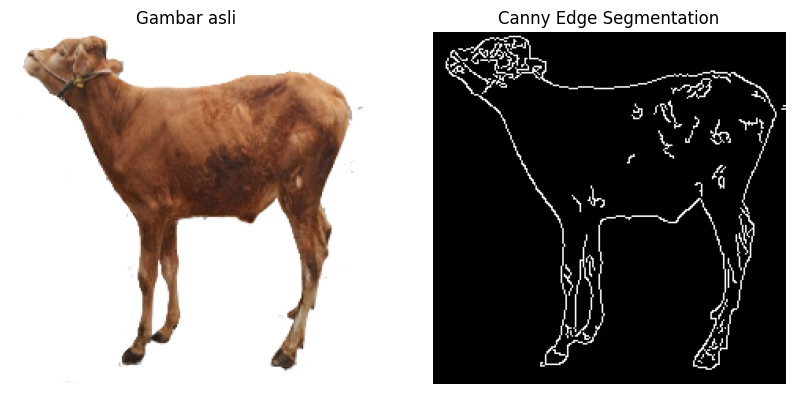

In [ ]:
def select_image_by_path(image_path):
    if os.path.exists(image_path):
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        return img_array
    else:
        print(f"Gambar dengan path {image_path} tidak ditemukan!")
        return None

image_path = '/content/dataset2/180.jpg'
selected_image = select_image_by_path(image_path)

if selected_image is not None:
    segmented_image = canny_edge_detection(selected_image)
    show_images(selected_image, segmented_image)

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    # Blok 1
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Blok 2
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Blok 3
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Blok 4 (Dikurangi agar tidak terlalu kompleks)
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),  # Tambahkan dropout untuk mengurangi overfitting
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    # Output Layer untuk regresi (Prediksi bobot sapi)
    tf.keras.layers.Dense(1, activation='linear')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import tensorflow as tf
import time

# Fungsi custom RMSE yang diperbaiki
def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Konversi y_true ke float32
    return tf.sqrt(tf.keras.backend.mean(tf.square(y_true - y_pred)))

# Compile model dengan RMSE
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', rmse]
)

# Callback untuk menyimpan model terbaik
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Mulai hitung waktu training
start_time = time.time()

# Training model
history = model.fit(
    X, y.astype('float32'),  # Pastikan y bertipe float32
    epochs=750,
    batch_size=32,
    callbacks=[checkpoint]
)

# Selesai hitung waktu training
end_time = time.time()
training_time = end_time - start_time
print(f"Waktu training: {training_time:.2f} detik")


Epoch 1/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 210367.4844 - mae: 408.6095 - rmse: 459.2382
Epoch 1: loss improved from inf to 210851.09375, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - loss: 210528.6875 - mae: 407.4241 - rmse: 459.5336
Epoch 2/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 134367.1562 - mae: 285.9323 - rmse: 363.8093
Epoch 2: loss improved from 210851.09375 to 119752.06250, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 129495.4609 - mae: 279.2827 - rmse: 356.9680
Epoch 3/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 83774.7500 - mae: 212.9161 - rmse: 286.6557
Epoch 3: loss improved from 119752.06250 to 70807.17969, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - loss: 79452.2266 - mae: 208.1280 - rmse: 279.3495
Epoch 4/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 55512.9375 - mae: 192.2610 - rmse: 268.9432
Epoch 4: loss improved from 70807.17969 to 58138.08594, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 56387.9883 - mae: 194.2437 - rmse: 268.0267
Epoch 5/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 42152.6172 - mae: 158.4871 - rmse: 271.9772
Epoch 5: loss improved from 58138.08594 to 41122.48438, saving model to best_model.h5


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 4077.2185 - mae: 49.6886 - rmse: 315.3840
Epoch 146/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 8947.1914 - mae: 64.1753 - rmse: 340.3349
Epoch 146: loss did not improve from 4335.70703
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 8987.9463 - mae: 65.3088 - rmse: 342.4820
Epoch 147/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 5160.0498 - mae: 57.2234 - rmse: 320.3965
Epoch 147: loss did not improve from 4335.70703
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 5087.8530 - mae: 56.9665 - rmse: 316.7033
Epoch 148/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 5266.4121 - mae: 59.7093 - rmse: 335.8783
Epoch 148: loss did not improve from 4335.70703
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 5732.3984 - mae: 61.6540 - rmse: 336.0188
Epoch 149/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 6968.1719 - mae: 61.9617 - rmse: 323.4482
Epoch 149: loss did not improve from 4335.70703
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 6890.6953 - mae:

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 4340.9829 - mae: 49.9772 - rmse: 316.5664
Epoch 175/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 11567.0449 - mae: 85.1912 - rmse: 363.9531
Epoch 175: loss did not improve from 4239.99121
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 10907.5293 - mae: 81.9339 - rmse: 353.1803
Epoch 176/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 9263.3770 - mae: 67.0731 - rmse: 288.4121
Epoch 176: loss did not improve from 4239.99121
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 10521.8008 - mae: 70.9741 - rmse: 295.5737
Epoch 177/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 6833.4131 - mae: 55.0513 - rmse: 315.3130
Epoch 177: loss did not improve from 4239.99121
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 6548.6846 - mae: 54.3964 - rmse: 320.0521
Epoch 178/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 9243.5605 - mae: 75.3012 - rmse: 332.7205 
Epoch 178: loss did not improve from 4239.99121
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 8653.4141 - 

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - loss: 3947.1177 - mae: 49.3976 - rmse: 312.4925
Epoch 280/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 6021.4785 - mae: 58.1595 - rmse: 314.0674
Epoch 280: loss did not improve from 3961.10889
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 6101.3906 - mae: 57.8137 - rmse: 310.6424
Epoch 281/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 10800.5527 - mae: 75.4123 - rmse: 295.9810
Epoch 281: loss did not improve from 3961.10889
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 10758.9990 - mae: 75.5224 - rmse: 298.2547
Epoch 282/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 5522.8105 - mae: 55.8655 - rmse: 334.0734
Epoch 282: loss did not improve from 3961.10889
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - loss: 5287.1714 - mae: 54.9226 - rmse: 325.7823
Epoch 283/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 5098.9531 - mae: 53.7765 - rmse: 328.8444
Epoch 283: loss did not improve from 3961.10889
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 5145.3022 - mae: 

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 3958.3828 - mae: 49.9574 - rmse: 297.8159
Epoch 295/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 7140.3887 - mae: 67.1444 - rmse: 277.4811
Epoch 295: loss did not improve from 3563.75977
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 7219.2202 - mae: 66.9355 - rmse: 286.3164
Epoch 296/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 9047.8564 - mae: 72.4383 - rmse: 325.0833
Epoch 296: loss did not improve from 3563.75977
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - loss: 9011.9668 - mae: 72.3649 - rmse: 319.5464
Epoch 297/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 11228.9961 - mae: 79.0328 - rmse: 308.1947
Epoch 297: loss did not improve from 3563.75977
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 10846.8105 - mae: 77.2591 - rmse: 304.6728
Epoch 298/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 7978.6636 - mae: 67.7055 - rmse: 314.0920
Epoch 298: loss did not improve from 3563.75977
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 8071.3179 - mae

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - loss: 2796.1943 - mae: 41.7259 - rmse: 312.2443
Epoch 443/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 8865.8604 - mae: 65.5958 - rmse: 316.2039
Epoch 443: loss did not improve from 2655.03125
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 8522.7832 - mae: 65.0974 - rmse: 310.8981
Epoch 444/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 6171.5986 - mae: 62.2086 - rmse: 320.7965
Epoch 444: loss did not improve from 2655.03125
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 6146.7354 - mae: 62.5062 - rmse: 314.7565
Epoch 445/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 4832.8540 - mae: 49.2236 - rmse: 307.2726
Epoch 445: loss did not improve from 2655.03125
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 4841.1650 - mae: 49.6356 - rmse: 311.0105
Epoch 446/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 4539.4131 - mae: 53.8491 - rmse: 330.6101
Epoch 446: loss did not improve from 2655.03125
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 4476.1714 - mae: 

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step


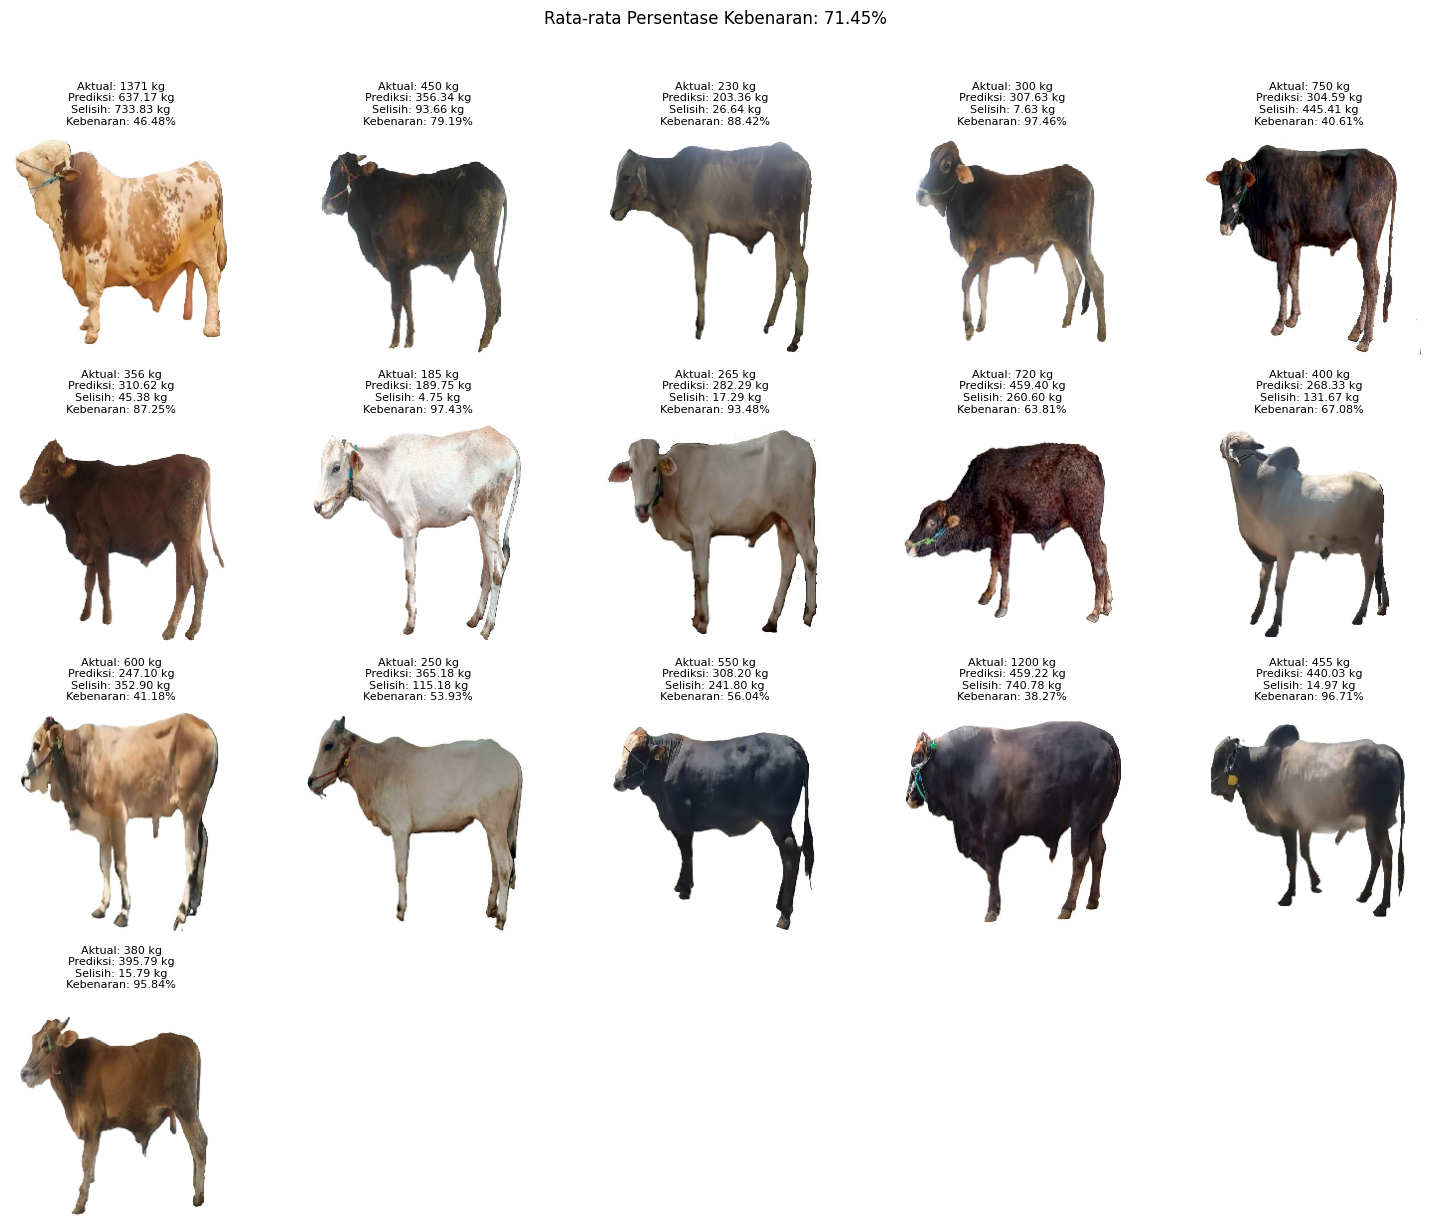

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test_dataset.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test_dataset'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)
num_images = len(X)

cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


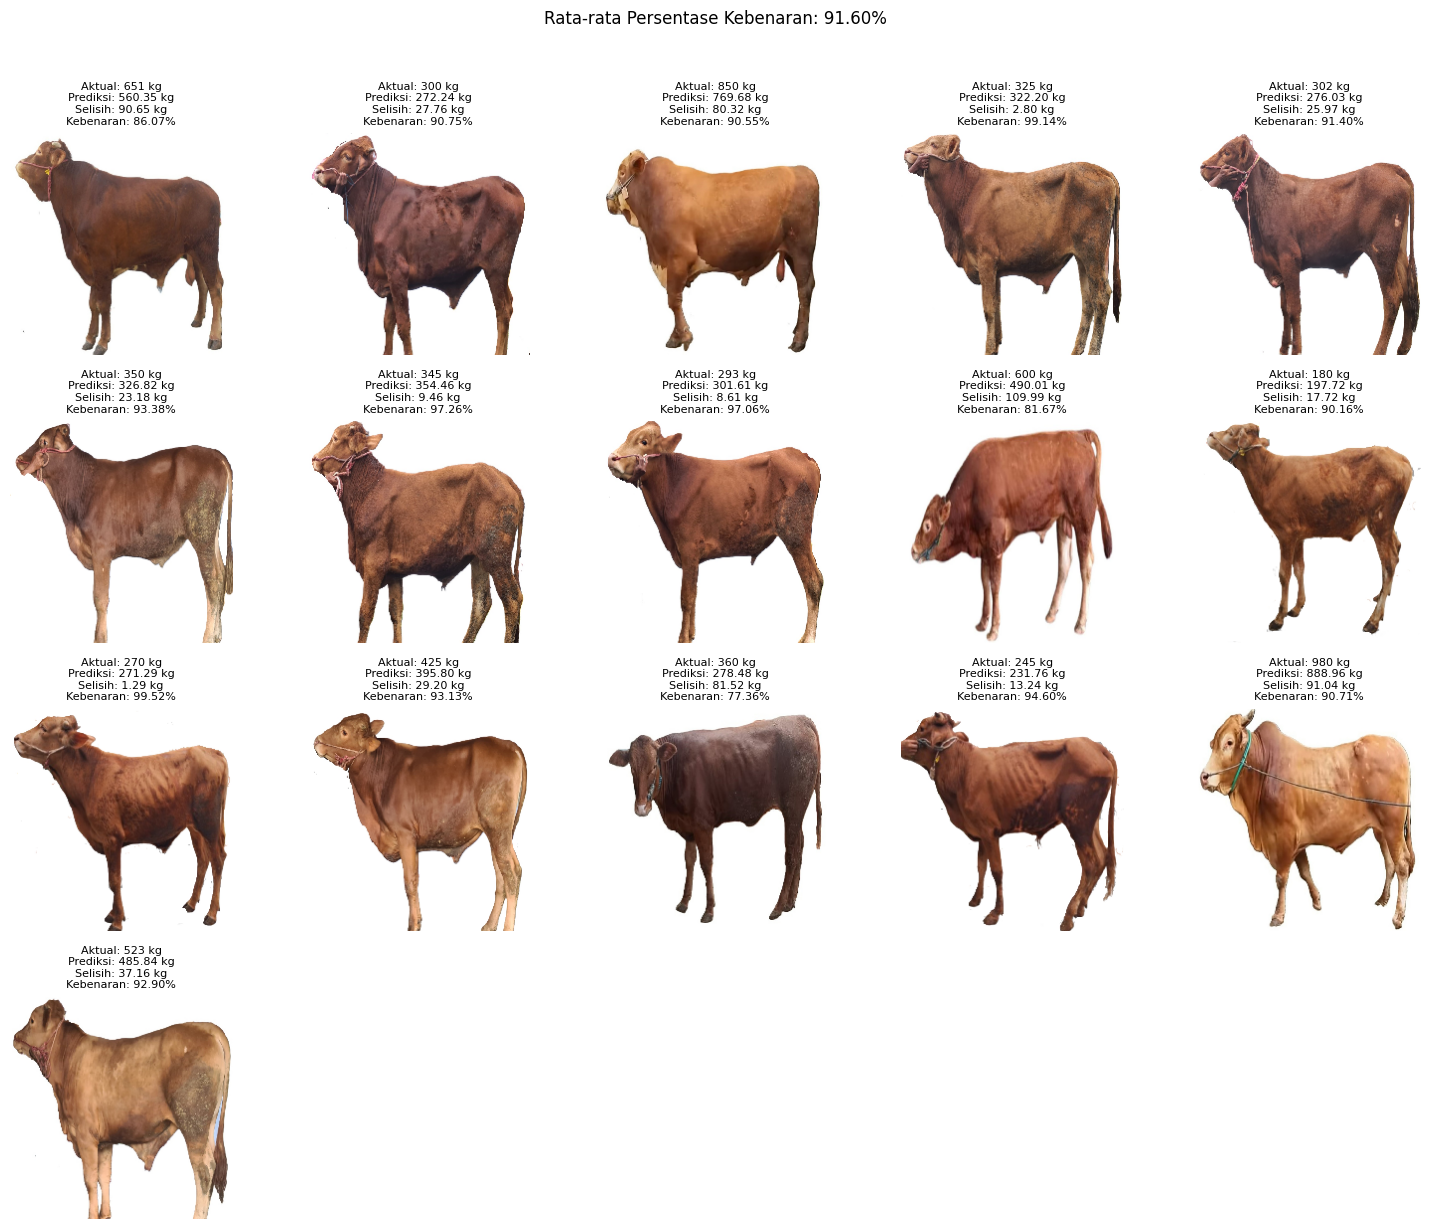

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/dataset2.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/dataset2'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


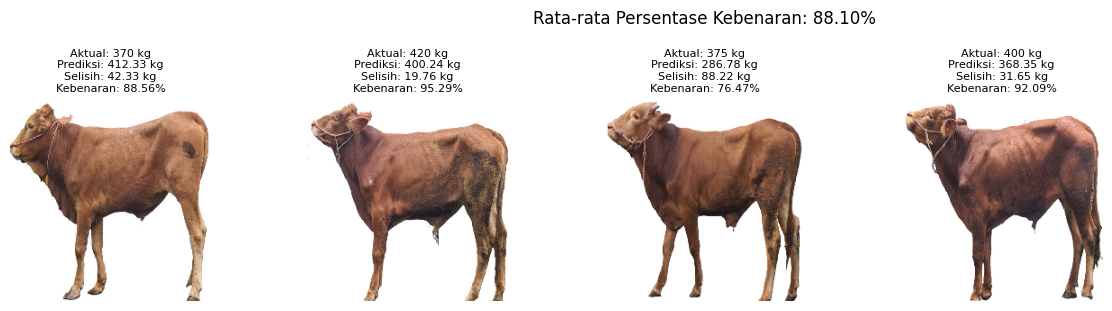

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

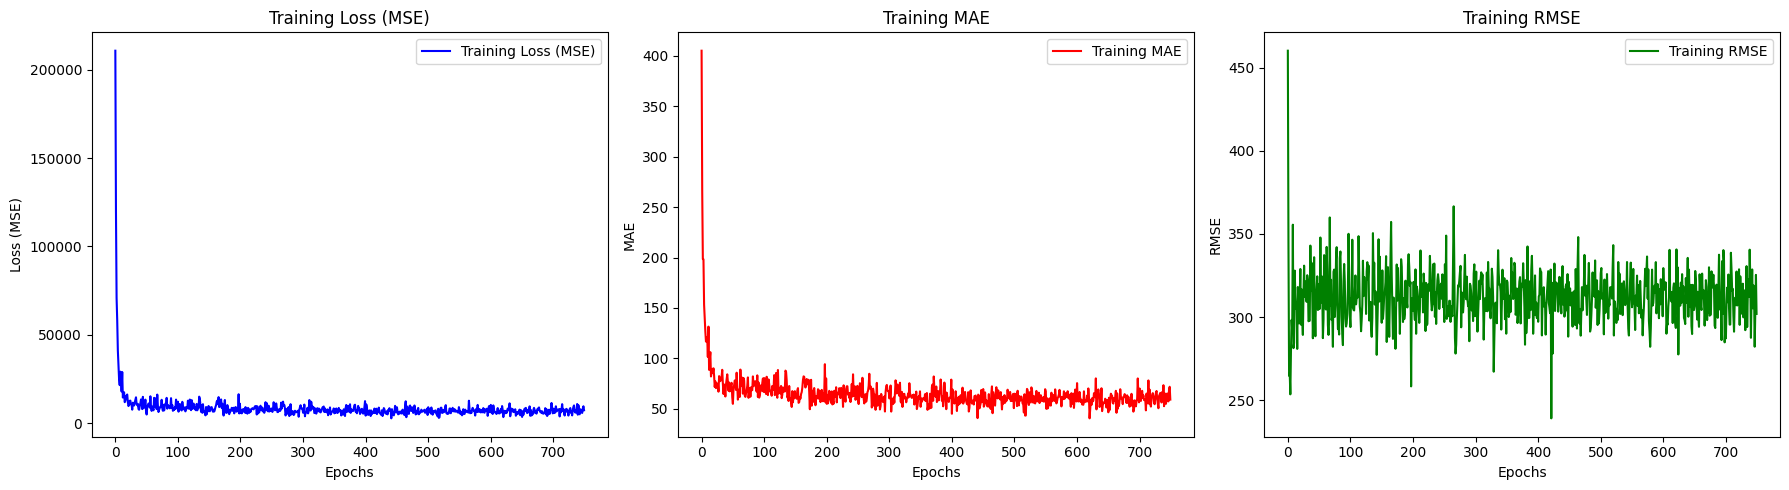

In [ ]:
plt.figure(figsize=(18, 5))

# Plot Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss (MSE)')
plt.legend()

# Plot Mean Absolute Error (MAE)
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', color='red')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training MAE')
plt.legend()

# Plot Root Mean Squared Error (RMSE)
plt.subplot(1, 3, 3)
plt.plot(history.history['rmse'], label='Training RMSE', color='green')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training RMSE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Ambil nilai MAE dan RMSE dari history
mae_values = history.history['mae']
rmse_values = history.history['rmse']

min_mae_index = mae_values.index(min(mae_values))

min_mae = mae_values[min_mae_index]
corresponding_rmse = rmse_values[min_mae_index]

print(f"MAE terkecil: {min_mae:.4f} pada epoch {min_mae_index + 1}")
print(f"RMSE pada epoch yang sama: {corresponding_rmse:.4f}")


MAE terkecil: 40.5752 pada epoch 621
RMSE pada epoch yang sama: 293.4745
